---
format:
  html:
    code-fold: true
    code-summary: "Mostrar código"
---

# Força magnética

O objetivo do documento é nortear o trabalho de atuadores eletromagnéticos, buscando compreender o seu funcionamento e dimensionamento. Serão adotadas duas abordagens. A primeira, considerando a primeira simulação, sem que o contator esteja totalmente fechado. A segunda, considera quando o contator está totalmente fechado. 

Dúvidas construtivas podem ser identificadas através do [modelo 3D](https://cad.onshape.com/documents/8820e8d7ea6dd44d51386efd/w/41ccc6ba8c1405b27ee3d5a3/e/479d4a41a35a66eb9f078fe4?renderMode=0&uiState=6321fcc030efd3042e25c955).

## Modelo com dois caminhos no entreferro

![](image002.jpg)

### Método analítico

$$ F = \frac{W_{mag}}{g} $$

Considerando apenas a relutância de entreferro

$$ F = \frac{\mu_0 A N^2 i^2}{4g^2} $$

Considerando a relutância total
$$ F = \frac{1}{2}\frac{L i^2}{g} $$

Para usar a relutância equivalente do circuito, o valor de $g$ entra apenas uma vez.

In [1]:
mu_0 = 4*pi*1e-7; % Permeabilidade magnética
N = 66; % Número de espiras
A = .5; % Polegadas quadrado
i = 1; % Corrente
g = .025; % Entreferro

In [2]:
% Pelo entreferro
F = mu_0 * A * N^2 * i^2 / (4*g^2)

F =  1.0948


![](relutancias.png)

In [3]:
% Pela relutância equivalente
mu_r = 2500; % Permeabilidade relativa do aço
mu = mu_r * mu_0;
l1 = .75 - .25/2; % Comprimento de l1
A1 = A;
R1 = 1/mu * l1 / A1; % Relutancia 1
% 2*R3 = R1
l2 = .25/2+.25+.25; % Comprimento de l2
A2 = A/2;
R2 = 1/mu * l2 / A2; % Relutancia 2
% R4 = R2
Rg = 1/mu_0 * g / A;
Rt = 2*R1 + 4*R2 + 2*Rg;
L = N^2 / Rt;
F = 1/2*L*i^2 / g

F =  1.0426


#### Montando uma "função" de cálculo

In [4]:
function [simplificado, completo] = forcaAnalitica2gap(g)
    mu_0 = 4*pi*1e-7; % Permeabilidade magnética
    N = 66; % Número de espiras
    A = .5; % Polegadas quadrado
    i = 1; % Corrente
    F = mu_0 * A * N^2 * i^2 ./ (4*g.^2);
    simplificado = F;
    % Pela relutância equivalente
    mu_r = 2500; % Permeabilidade relativa do aço
    mu = mu_r * mu_0;
    l1 = .75 - .25/2; % Comprimento de l1
    A1 = A;
    R1 = 1/mu * l1 / A1; % Relutancia 1
    % 2*R3 = R1
    l2 = .25/2+.25+.25; % Comprimento de l2
    A2 = A/2;
    R2 = 1/mu * l2 / A2; % Relutancia 2
    % R4 = R2
    Rg = 1/mu_0 * g / A;
    Rt = 2*R1 + 4*R2 + 2*Rg;
    L = N^2 ./ Rt;
    F = 1/2*L*i^2 ./ g;
    completo = F;
end

#### Gráfico

In [5]:
g = linspace(.01,.04, 100);
[F_2gap, F_2total] = forcaAnalitica2gap(g);

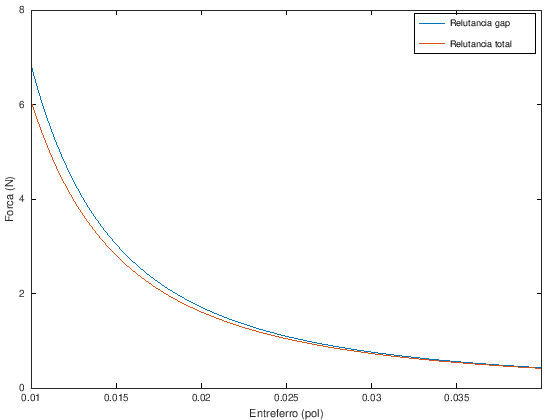

In [6]:
plot(g, [F_2gap' F_2total'], 'Linewidth', 3)
axis([.01 .04 0 8]);
%set (gca (), "xdir", "reverse")
xlabel('Entreferro (pol)'); ylabel('Forca (N)');
legend('Relutancia gap', 'Relutancia total');

### Método elementos finitos

In [7]:
if (~isempty( strfind(computer(), "w64") ) )
    addpath("C:\\femm42\\mfiles"); 
else
    addpath("~/.wine/drive_c/femm42/mfiles"); 
end

In [8]:
openfemm;
opendocument('induct1a.fem');
mi_saveas('temp.FEM');
g_2femm = linspace(.01, .04, 20);
F_2femm = [];
dgap = g_2femm(2) - g_2femm(1);
for i = g_2femm
    % Resolve
    mi_analyze;
    mi_loadsolution;
    mo_selectblock(0,-.04);
    F_2femm = [F_2femm mo_blockintegral(19)];
    mo_clearblock;
    mo_close;
    
    %Desloca
    mi_selectgroup(5);
    mi_movetranslate(0,-dgap);
    mi_clearselected;
    
end

In [9]:
closefemm;

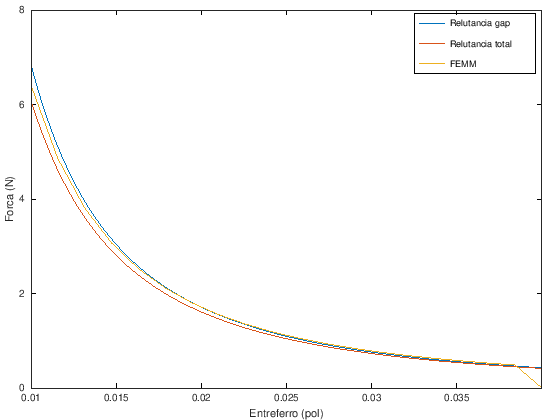

In [10]:
plot(g, [F_2gap' F_2total'], g_2femm, F_2femm, 'Linewidth', 3)
axis([.01 .04 0 8]);
%set (gca (), "xdir", "reverse")
xlabel('Entreferro (pol)'); ylabel('Forca (N)');
legend('Relutancia gap', 'Relutancia total', 'FEMM');

A força está associada a variação da relutância no entreferro. 
1. Ao considerar a relutância total, ela varia menos que considerar apenas a relutância do gap.
2. Variar menos significa que a força da relutância total será menor que considerar todo o gap.
3. No FEMM o modelo é completo. Apesar da dispernsão da bobina paralela ao plano não ser modelada, ele apresenta boa conformidade com o resultado.

## Modelo com um caminho no entreferro - contator

![](relutancias1gap.png)

#### Montando uma função de cálculo

In [11]:
function [simplificado, completo] = forcaAnalitica1gap(g)
    mu_0 = 4*pi*1e-7; % Permeabilidade magnética
    N = 66; % Número de espiras
    A = .5; % Polegadas quadrado
    i = 1; % Corrente
    F = mu_0 * A * N^2 * i^2 ./ (2*g.^2);
    simplificado = F;
    % Pela relutância equivalente
    mu_r = 2500; % Permeabilidade relativa do aço
    mu = mu_r * mu_0;
    l1 = .75 - .25/2; % Comprimento de l1
    A1 = A;
    R1 = 1/mu * l1 / A1; % Relutancia 1
    % 2*R3 = R1
    l2 = .25/2+.25+.25; % Comprimento de l2
    A2 = A/2;
    R2 = 1/mu * l2 / A2; % Relutancia 2
    % R4 = R2
    Rg = 1/mu_0 * g / A;
    Rt = 2*R1 + 4*R2 + Rg;
    L = N^2 ./ Rt;
    F = 1/2*L*i^2 ./ g;
    completo = F;
end

In [12]:
[F_1gap, F_1total] = forcaAnalitica1gap(g);

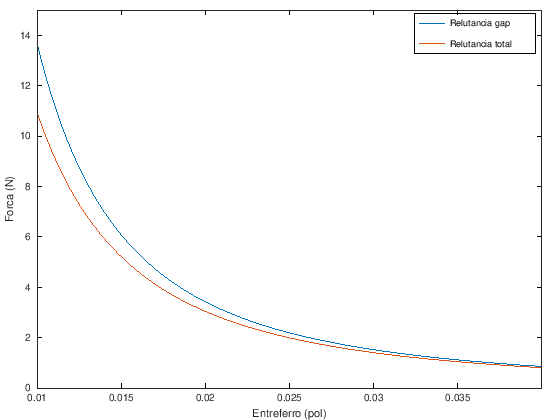

In [13]:
plot(g, [F_1gap' F_1total' ], 'Linewidth', 3)
axis([.01 .04 0 15]);
%set (gca (), "xdir", "reverse")
xlabel('Entreferro (pol)'); ylabel('Forca (N)');
legend('Relutancia gap', 'Relutancia total');

Como era de se esperar, a força cresce pois reduzimos um caminho de relutância.

### Método elementos finitos

In [14]:
openfemm;
opendocument('induct1a_1gap_adj.fem');
mi_saveas('temp.FEM');
g_1femm = linspace(.01, .04, 20);
F_1femm_adj_dir = [];
F_1femm_adj_ene = [];
dgap = g_2femm(2) - g_2femm(1);
for i = g_1femm
    % Resolve
    mi_analyze;
    mi_loadsolution;
    mo_selectblock(0,-.04);
    F_1femm_adj_dir = [F_1femm_adj_dir mo_blockintegral(19)];
    mo_clearblock;
    mo_groupselectblock(0);
    F_1femm_adj_ene = [F_1femm_adj_ene mo_blockintegral(2)/(i*0.0254)];
    mo_clearblock;
    mo_close;
    
    %Desloca
    mi_selectgroup(4);
    mi_movetranslate(0,dgap);
    mi_clearselected;
    
end

In [15]:
closefemm;

In [16]:
openfemm;
opendocument('induct1a_1gap_ene.fem');
mi_saveas('temp.FEM');
F_1femm_ene = [];
%dgap = g_2femm(2) - g_2femm(1);
for i = g_1femm
    % Resolve
    mi_analyze;
    mi_loadsolution;
    mo_groupselectblock(0)
    F_1femm_ene = [F_1femm_ene mo_blockintegral(2)/(i*0.0254)];
    mo_clearblock;
    mo_close;
    
    %Desloca
    mi_selectgroup(4);
    mi_movetranslate(0,dgap);
    mi_clearselected;
    
end

In [19]:
closefemm;

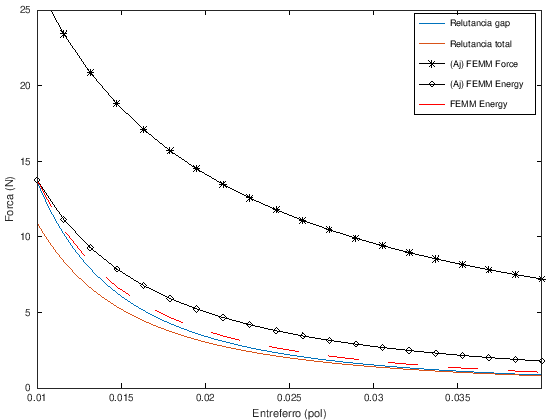

In [21]:
plot(g, [F_1gap' F_1total'], g_1femm, F_1femm_adj_dir, '-*k', g_1femm, F_1femm_adj_ene, '-dk', g_1femm, F_1femm_ene, '--r',  'Linewidth', 3)
axis([.01 .04 0 25]);
%set (gca (), "xdir", "reverse")
xlabel('Entreferro (pol)'); ylabel('Forca (N)');
legend('Relutancia gap', 'Relutancia total', '(Aj) FEMM Force', '(Aj) FEMM Energy', 'FEMM Energy');

A força está associada a variação da relutância no entreferro. 
1. Ao considerar a relutância total, ela varia menos que considerar apenas a relutância do gap.
2. Variar menos significa que a força da relutância total será menor que considerar todo o gap.
3. No FEMM o modelo é completo. Apesar da dispernsão da bobina paralela ao plano não ser modelada, ele apresenta boa conformidade com o resultado.